# Algorithmic Fairness, Accountability, and Ethics, Spring 2026

# Exercise 4

## Task 0 (Setup)

We use the same dataset as in week 2 and 3. If you missed to install the module, please carry out the installation tasks at <https://github.com/zykls/folktables#basic-installation-instructions>.

After successful installation, you should be able to run the following code to generate a prediction task.
To make your life easier, we made the `BasicProblem`-magic from the `folktables` package (see exercises of week 2) explicit in this task.
This way, you can get access to different encodings of the data. 

In [24]:
from folktables.acs import adult_filter
from folktables import ACSDataSource
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

data_source = ACSDataSource(survey_year='2018', horizon='1-Year', survey='person')
acs_data = data_source.get_data(states=["CA"], download=True)

feature_names = ['AGEP', # Age
                 "CIT", # Citizenship status
                 'COW', # Class of worker
                 "ENG", # Ability to speak English
                 'SCHL', # Educational attainment
                 'MAR', # Marital status
                 "HINS1", # Insurance through a current or former employer or union
                 "HINS2", # Insurance purchased directly from an insurance company
                 "HINS4", # Medicaid
                 "RAC1P", # Recoded detailed race code
                 'SEX']

target_name = "PINCP" # Total person's income

def data_processing(data, features, target_name:str, threshold: float = 25000):
    df = data
    ### Adult Filter (STARTS) (from Foltktables)
    df = df[~df["SEX"].isnull()]
    df = df[~df["RAC1P"].isnull()]
    df = df[df['AGEP'] > 16]
    df = df[df['PINCP'] > 100]
    df = df[df['WKHP'] > 0]
    df = df[df['PWGTP'] >= 1]
    ### Adult Filter (ENDS)
    ### Groups of interest
    sex = df["SEX"].values
    ### Target
    df["target"] = df[target_name] > threshold
    target = df["target"].values
    df = df[features + ["target", target_name]] ##we want to keep df before one_hot encoding to make Bias Analysis
    df_processed = df[features].copy()
    cols = [ "HINS1", "HINS2", "HINS4", "CIT", "COW", "SCHL", "MAR", "SEX", "RAC1P"]
    df_processed = pd.get_dummies(df_processed, prefix=None, prefix_sep='_', dummy_na=False, columns=cols, drop_first=True)
    df_processed = pd.get_dummies(df_processed, prefix=None, prefix_sep='_', dummy_na=True, columns=["ENG"], drop_first=True)
    return df_processed, df, target, sex

data, data_original, target, group = data_processing(acs_data, feature_names, target_name)

X_train, X_test, y_train, y_test, group_train, group_test = train_test_split(
    data, target, group, test_size=0.2, random_state=0)

cols = data_original.columns

cols = cols[:-2]

X_train, X_test, y_train, y_test, group_train, group_test = train_test_split(
    data_original[cols], target, group, test_size=0.2, random_state=0)

X_train.loc[X_train.ENG.isna(), 'ENG'] = 0 # Fill missing values with 0, shap gets upset with NaNs
X_test.loc[X_test.ENG.isna(), 'ENG'] = 0

# Task

1. Train a black-box model classifier (for example, use a random forest, a gradient-boosted decision tree, an SVM, or a Neural Network). Report on its accuracy. If you have used a tree data structure such as RF or gradient-boosted decision trees, report on the feature importance.


In [25]:
scaler = ColumnTransformer(
    [('scaler', StandardScaler(),['AGEP'])], 
    remainder='passthrough')

scaler.fit(X_train) #Make sure we fit to the training data only, to avoid data leakage
X_train.AGEP = scaler.transform(X_train)[:,0]
X_test.AGEP = scaler.transform(X_test)[:,0]

clf = RandomForestClassifier(max_depth=10, 
                             random_state=23, 
                             n_jobs=-1, 
                             n_estimators=50) 

clf.fit(X_train, y_train)
accuracy = clf.score(X_test, y_test)
print(f"Accuracy on test data: {accuracy:.4f}")

# Get feature importances
importances = clf.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)

feature_importance_df.head(10)

Accuracy on test data: 0.7991


,feature,importance
0,AGEP,0.389883
6,HINS1,0.145338
8,HINS4,0.128111
4,SCHL,0.114822
5,MAR,0.079243
10,SEX,0.043850
3,ENG,0.037933
2,COW,0.020045
1,CIT,0.019440
7,HINS2,0.011227


2. Use the `shap` module to explain predictions on your black-box model. 

In [47]:
import shap
shap.initjs()

X_train_num = X_train.astype(np.float32)
X_test_num  = X_test.astype(np.float32)

explainer = shap.TreeExplainer(clf, X_train_num, model_output="probability")

shap_values = explainer(X_test_num)  

100%|===================| 78244/78266 [07:47<00:00]        

As shown in the lecture, provide a summary plot, a dependence plot,  a  force plot for a negatively/positively predicted feature vector, and summary plot on the interaction values.

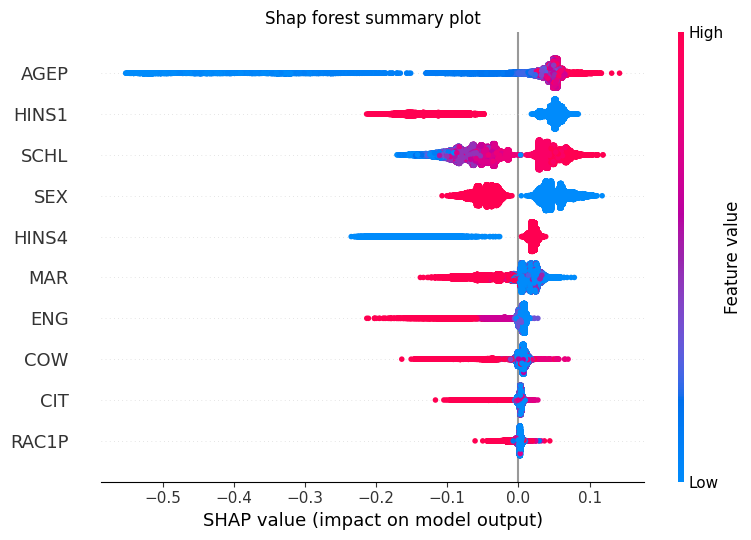

In [ ]:
import matplotlib.pyplot as plt

# SUMMARY PLOT

## Which features matters most overall
## Dots: Individuals in the test set
## Y-axis: features, sorted by importance
## X axis: SHAP value, the impact of the feature on the model output (positive or negative)
## Color: the value of the feature (red high, blue low)
## “If red dots for AGEP are mostly on the right, higher age tends to increase probability of >25k.”

## Summary plot
shap.summary_plot(shap_values[:,:,1], X_test, 
                  feature_names=X_train.columns, 
                  max_display=10, show=False)

plt.title(f'Shap forest summary plot')
plt.tight_layout()

plt.show()

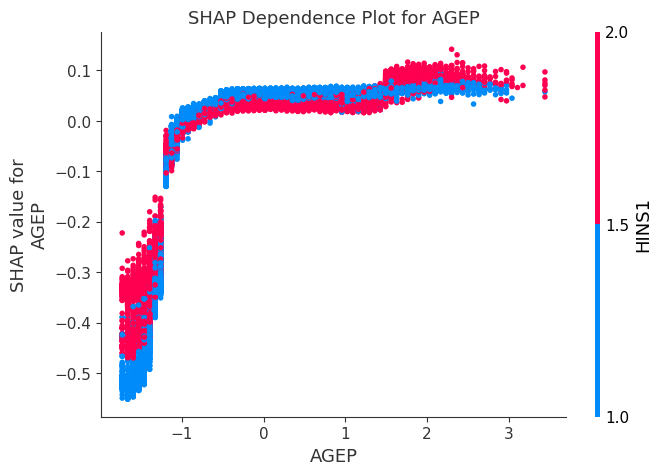

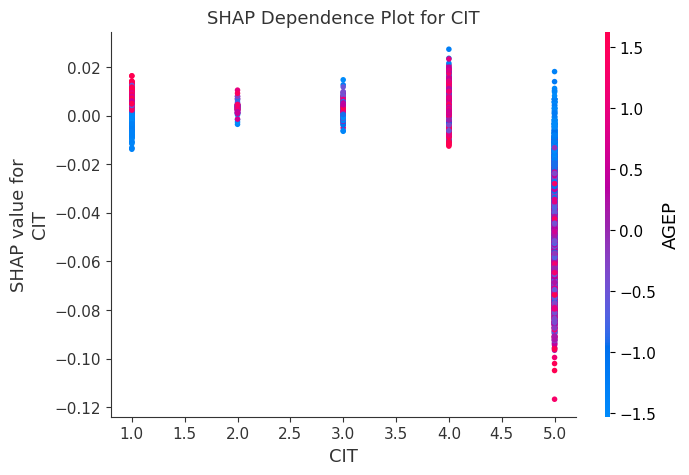

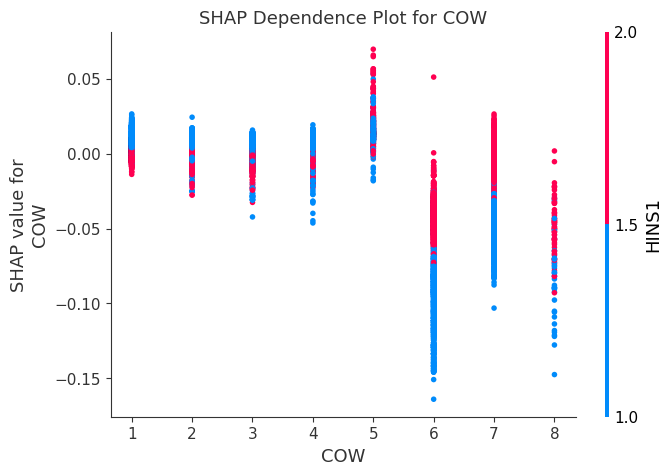

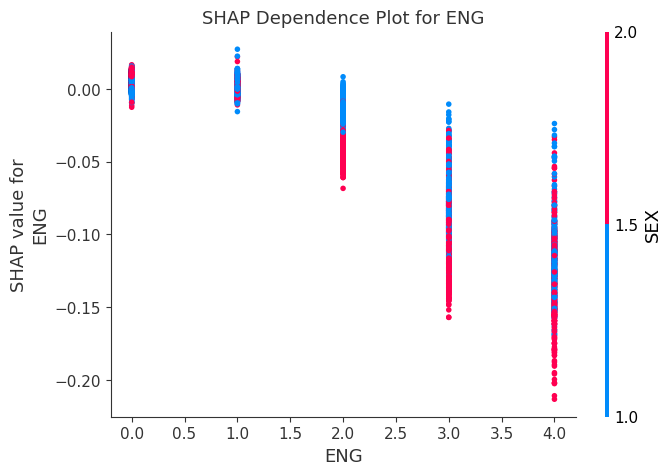

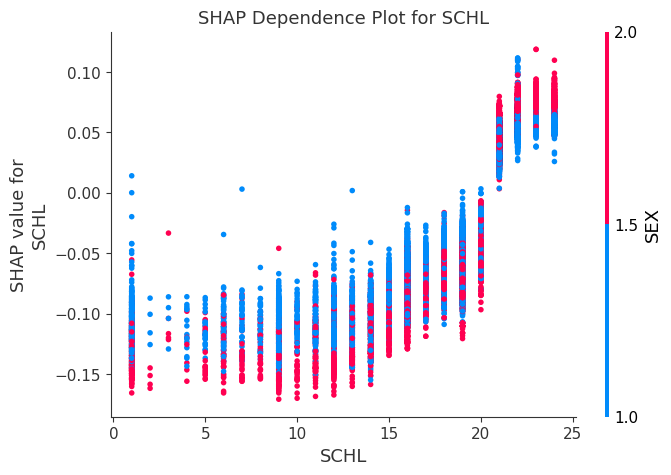

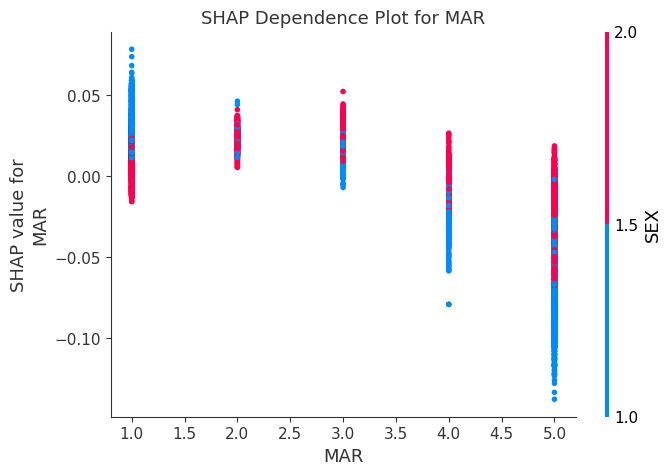

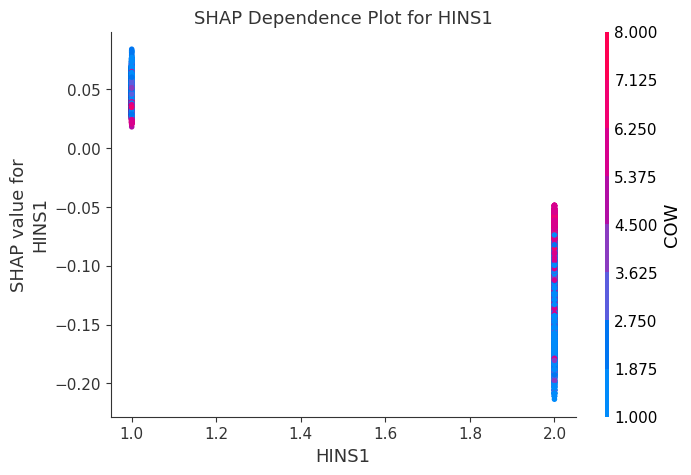

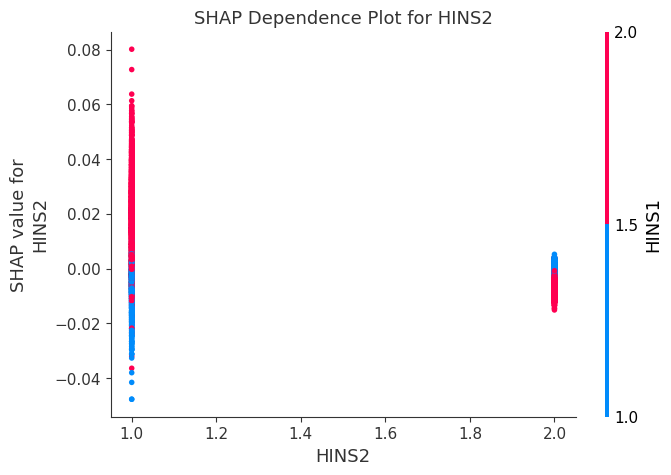

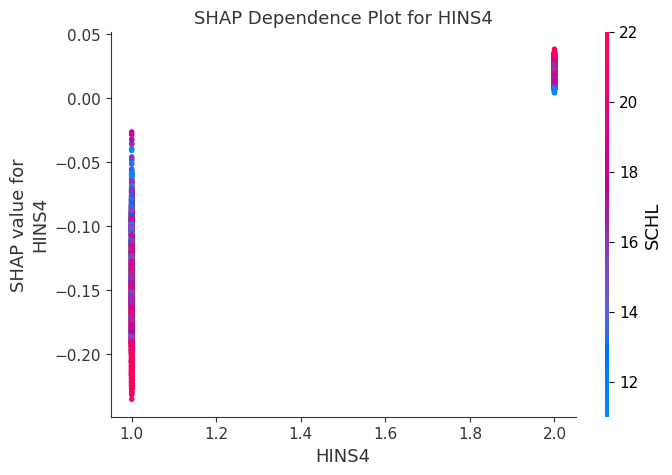

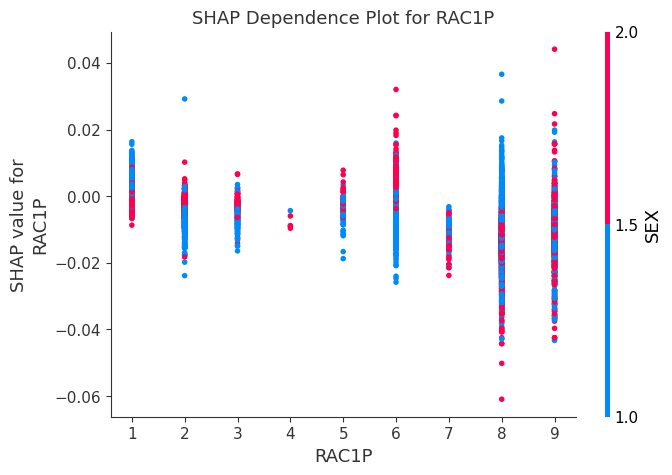

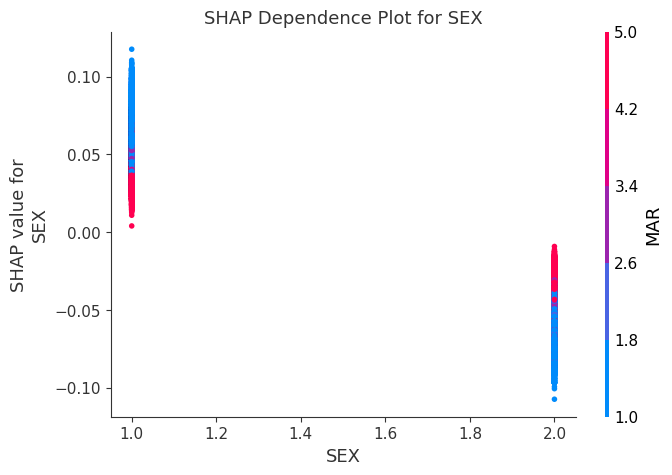

In [ ]:
# DEPENDENCE PLOTS

## How the value of one feature affects the model’s prediction across all individuals.
## X-axis: the value of the feature
## Y-axis: the SHAP value of the feature, the impact of the feature on the model output (positive or negative)
## Color: the value of another feature, often a feature that is correlated with the feature being plotted
## Dots: Individuals in the test set

# Interpretation: 
## Upward trend → higher feature values increase probability of positive outcome
## Downward trend → higher feature values decrease probability
## Flat → little effect

for name in X_train.columns:
    shap.dependence_plot(name, shap_values.values[:,:,1], 
                         X_test, title=f'SHAP Dependence Plot for {name}')

In [ ]:
# FORCE PLOTS 

## Why did the model make a specific prediction for an individual?
## The baseline (expected_value) is the model’s average predicted probability for class 1 on the background data
## Red features push the prediction UP (toward class 1 / higher income).
## Blue features push it DOWN.
## The forces add up from the baseline to the final prediction for that person.


proba = clf.predict_proba(X_test_num)[:,1]
pred = proba >= 0.5
dp_pos = np.where(pred)[0][0]
dp_neg = np.where(~pred)[0][0]

cl = 1  # class 1 = income >25k

base = explainer.expected_value[cl]

shap.plots.force( # predicted as positive 
    base,
    shap_values.values[dp_pos, :, cl],
    X_test_num.iloc[dp_pos, :]
)


In [ ]:
shap.plots.force( # predicted as negative
    base,
    shap_values.values[dp_neg, :, cl],
    X_test_num.iloc[dp_neg, :]
)

In [ ]:
# DEPENDENCE PLOT FOR INTERACTION VALUES

## How much two features together contribute beyond their individual effects.

explainer2 = shap.TreeExplainer(model=clf) #If we don't get output for probabilities, we can look at the interaction values

In [ ]:

shap_interaction_values = explainer2.shap_interaction_values(X_train_num)
shap_inter_class1 = shap_interaction_values[1]

shap.dependence_plot(
    ('AGEP', 'HINS1_2'),   # interaction between age and insurance
    shap_inter_class1,
    X_test_num,
    feature_names=X_test_num.columns
)



Do the same with a white-box model that you have trained during last week's exercises.





Contrast the two models to each other: What are similarities, how do they differ? 





3. Reflect on the explanations: How does the white box models's (from last week) black-box explanation relate to its white-box explanation? Which classifier would you prefer when deploying a model as part of the machine learning pipeline? 